## Step5-Sense-Checking

Makes a few key plots of the final thermal forcing files to check for possible bugs.

Creator: Donald Slater, donald.slater@ed.ac.uk

Cleaned up by Donald Slater, 13 Mar 2026.

#### Required files/inputs
- CMIP monthly bias-corrected ocean thermal forcing, split into annual files e.g. *tf_CESM2-WACCM_historical_1850.nc*

#### Outputs
- Maps of thermal forcing and thermal forcing change over 20-yr time periods
- Annual time series of ocean thermal forcing from 4 large glaciers
- Seasonality of ocean thermal forcing for the same glaciers

In [1]:
# imports
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# inputs
cmip_model = 'CESM2-WACCM' # cmip model
scenario = 'ssp585' # scenario

# directories
hist_dir = '/Users/dslater2/Documents/' + cmip_model + '/historical/TF/' # historical files
proj_dir = '/Users/dslater2/Documents/' + cmip_model + '/' + scenario + '/TF/' # projection files
plot_dir = '/Users/dslater2/Documents/' + cmip_model + '/plots/' # directory to save plots

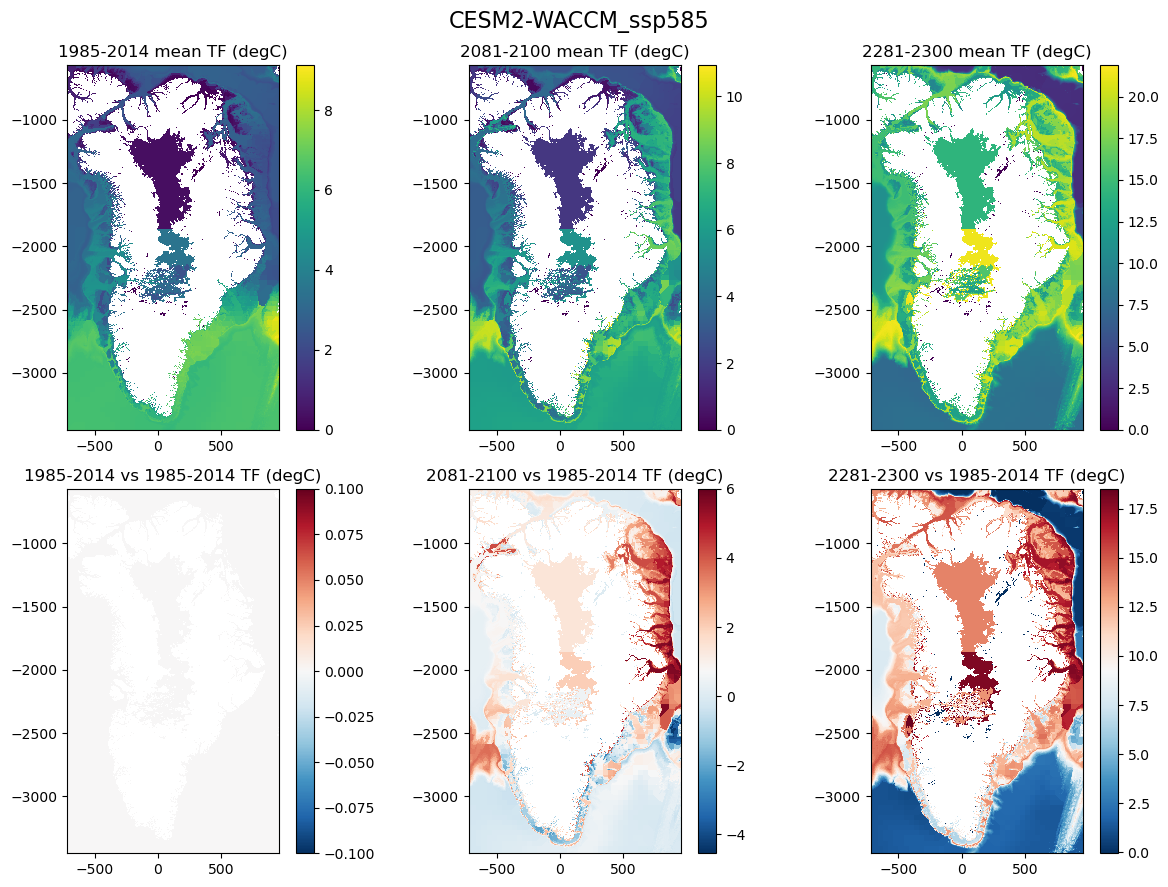

In [4]:
# map plots of TF and TF change

# periods
start_yrs = [1985, 2081, 2281]
end_yrs   = [2014, 2100, 2300]
means = [] 

for i, (start, end) in enumerate(zip(start_yrs, end_yrs)):

    TFs = []

    for year in range(start, end + 1):
        if year <=2014:
            file = hist_dir + 'TF_' + cmip_model + '_historical_' + str(year) + '.nc'
        else:
            file = proj_dir + 'TF_' + cmip_model + '_ssp585_' + str(year) + '.nc'
        ds = xr.open_dataset(file)

        if year == start:
            x = ds["x"]/1e3 # in km
            y = ds["y"]/1e3 # in km

        TFs.append(ds["TF"].mean(axis=0))  # annual mean

    # mean over all years in period
    TF_mean = xr.concat(TFs, dim="year").mean("year")
    means.append(TF_mean)

# --- plotting ---
fig, axes = plt.subplots(2, 3, figsize=(12, 9))

# row 1: means
for i in range(3):
    pcm = axes[0, i].pcolormesh(x, y, means[i], shading="auto", cmap="viridis")
    axes[0, i].set_title(f"{start_yrs[i]}-{end_yrs[i]} mean TF (degC)")
    axes[0, i].set_aspect("equal")
    fig.colorbar(pcm, ax=axes[0, i])

# row 2: differences relative to first period
for i in range(3):
    diff = means[i] - means[0]

    pcm = axes[1, i].pcolormesh(x, y, diff, shading="auto", cmap="RdBu_r")
    axes[1, i].set_title(f"{start_yrs[i]}-{end_yrs[i]} vs {start_yrs[0]}-{end_yrs[0]} TF (degC)")
    axes[1, i].set_aspect("equal")
    fig.colorbar(pcm, ax=axes[1, i])

fig.suptitle(cmip_model+'_'+scenario, fontsize=16)
plt.tight_layout()
plt.savefig(plot_dir+'plots_'+cmip_model+'_'+scenario+'_TF_map.png', dpi=300, bbox_inches="tight")
plt.show()

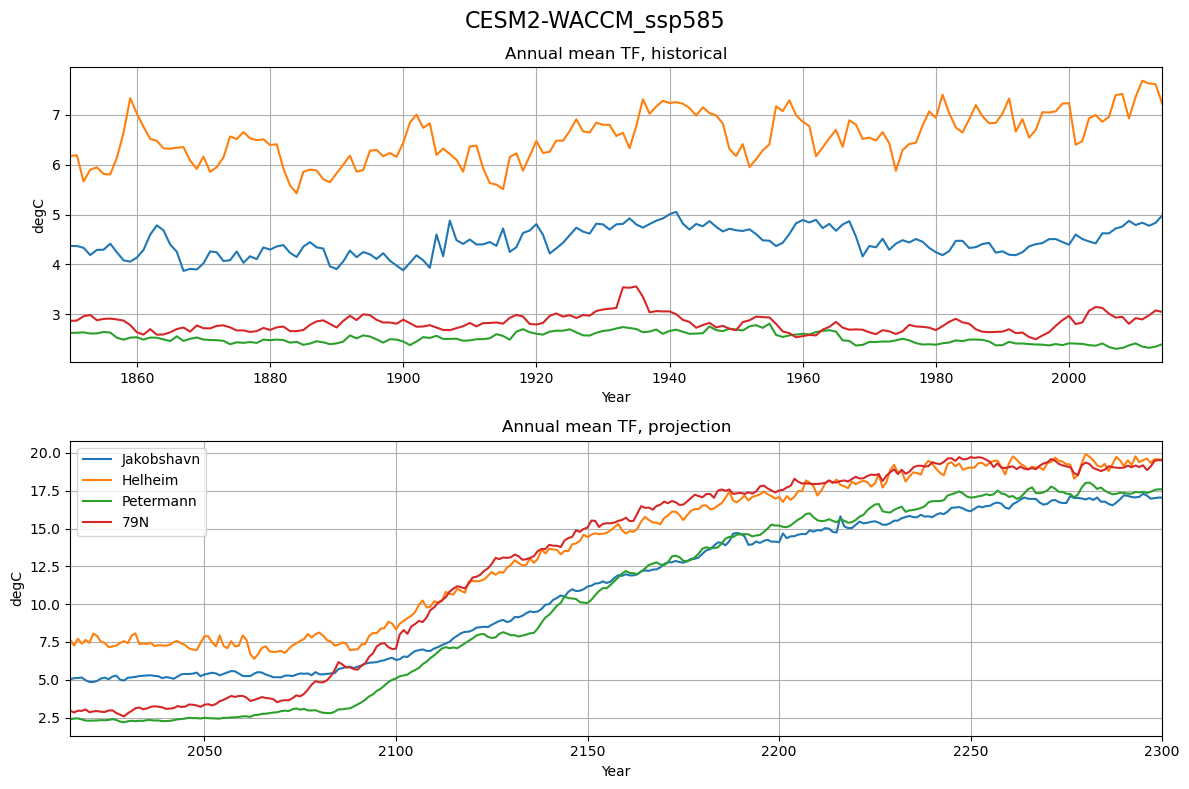

In [6]:
# time series plots - annual

# Period
start_yr = 1850
end_yr   = 2300

# Positions to extract (meters)
xpos = [-197975,  313225,   -273575,  459475]
ypos = [-2271580, -2578020, -938675, -1039020]
namepos = ['Jakobshavn', 'Helheim', 'Petermann', '79N']

# Initialize storage
TF_monthly = {f"point_{i}": [] for i in range(len(xpos))}
TF_annual  = {f"point_{i}": [] for i in range(len(xpos))}
time_all  = []

# Loop over years
for year in range(start_yr, end_yr + 1):

    if year <= 2014:
        file = f"{hist_dir}/TF_{cmip_model}_historical_{year}.nc"
    else:
        file = f"{proj_dir}/TF_{cmip_model}_ssp585_{year}.nc"

    with xr.open_dataset(file) as ds:

        # Extract x/y coordinates once
        if year == start_yr:
            x = ds["x"].values
            y = ds["y"].values

            # Find nearest indices for all points
            indices = [(np.abs(x - xp).argmin(), np.abs(y - yp).argmin()) for xp, yp in zip(xpos, ypos)]

        # Store time once per file
        time_all.append(ds["time"].values)

        # Extract TF for each point
        for i, (ix, iy) in enumerate(indices):
            TF_month = ds["TF"][:, iy, ix].values  # monthly values
            TF_monthly[f"point_{i}"].append(TF_month)
            TF_annual[f"point_{i}"].append(TF_month.mean())  # annual mean

# Convert lists to arrays
for i in range(len(xpos)):
    TF_monthly[f"point_{i}"] = np.concatenate(TF_monthly[f"point_{i}"])  # shape (n_months_total,)
    TF_annual[f"point_{i}"] = np.array(TF_annual[f"point_{i}"])          # shape (n_years_total,)

# Flatten time array
time_index = np.concatenate(time_all)

# annual mean plots
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Convert cftime to decimal year
def cftime_to_year(t):
    return t.year + (t.month - 1)/12 + (t.day - 1)/365
years_decimal = np.array([cftime_to_year(t) for t in time_index])
years_annual = np.floor(years_decimal)[::12]

# historical
mask_hist = (years_annual >= 1850) & (years_annual <= 2014)
for i in range(len(xpos)):
    axes[0].plot(years_annual[mask_hist], TF_annual[f"point_{i}"][mask_hist],label=namepos[i], linewidth=1.5)
axes[0].set_title('Annual mean TF, historical')
axes[0].set_xlabel("Year")
axes[0].set_ylabel("degC")
axes[0].grid(True)
axes[0].set_xlim(1850,2014)

# projection
mask_proj = (years_annual >= 2015) & (years_annual <= 2300)
for i in range(len(xpos)):
    axes[1].plot(years_annual[mask_proj], TF_annual[f"point_{i}"][mask_proj],label=namepos[i], linewidth=1.5)
axes[1].set_title('Annual mean TF, projection')
axes[1].set_xlabel("Year")
axes[1].set_ylabel("degC")
axes[1].grid(True)
axes[1].legend(loc='upper left')
axes[1].set_xlim(2015,2300)

fig.suptitle(cmip_model+'_'+scenario, fontsize=16)
plt.tight_layout()
plt.savefig(plot_dir+'plots_'+cmip_model+'_'+scenario+'_TF_annualtimeseries.png', dpi=300, bbox_inches="tight")
plt.show()

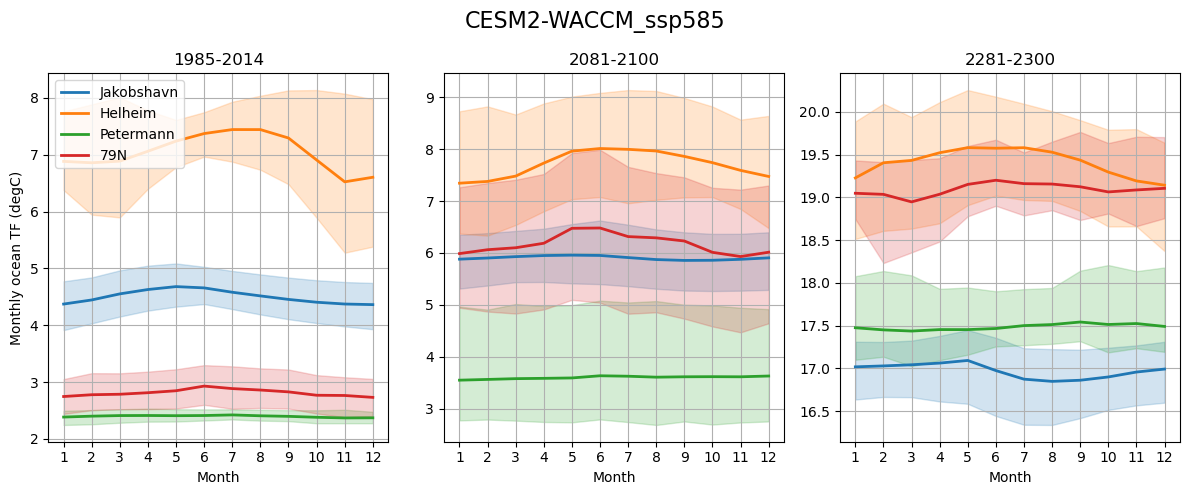

In [7]:
# check seasonality

# Periods
start_yrs = [1985, 2081, 2281]
end_yrs   = [2014, 2100, 2300]

# Colors for each glacier
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# Create figure with 3 subplots in a row
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

months = np.arange(1, 13)

for ax, (start, end) in zip(axes, zip(start_yrs, end_yrs)):
    for j, point in enumerate(namepos):
        # Mask for current period
        mask = (years_decimal >= start) & (years_decimal <= end)
        TF_period = TF_monthly[f"point_{j}"][mask]

        # Compute monthly min, max, mean
        TFmin = np.zeros(12)
        TFmax = np.zeros(12)
        TFmean = np.zeros(12)
        for i in range(12):
            month_vals = TF_period[i::12]
            TFmin[i] = month_vals.min()
            TFmax[i] = month_vals.max()
            TFmean[i] = month_vals.mean()

        # Shaded min-max range
        ax.fill_between(months, TFmin, TFmax, color=colors[j], alpha=0.2)

        # Solid mean line
        ax.plot(months, TFmean, color=colors[j], linewidth=2, label=point)

    # Customize subplot
    ax.set_xticks(months)
    ax.set_xlabel("Month")
    ax.set_title(f"{start}-{end}")
    ax.grid(True)

# Add y-label to leftmost subplot
axes[0].set_ylabel("Monthly ocean TF (degC)")

# Legend (only once, using the first subplot)
axes[0].legend(loc='upper left')

fig.suptitle(cmip_model+'_'+scenario, fontsize=16)
plt.tight_layout()  # leave space for suptitle
plt.savefig(plot_dir+'plots_'+cmip_model+'_'+scenario+'_TF_seasonal.png', dpi=300, bbox_inches="tight")
plt.show()